# Calculation of the ground state energy of the helium atom
# All-electrons ECG basis functions - Julia

|||
|-|-|
|**Authors:** |Alain Chancé|
|**Lead investigator:** |Alain Chancé|
|**Date:** |June 4, 2023|
|**Version:** |**1.00**<br/>*Details see at the end of this notebook*|
|**References:**|
[Lucas Lang, Henrique M. Cezar, Ludwik Adamowicz, and Thomas B. Pedersen, Quantum Definition of Molecular Structure, J. Am. Chem. Soc. 2024, 146, 3, 1760–1764, January 10, 2024]( https://doi.org/10.1021/jacs.3c11467)
[MolStructSampling.jl package evaluating the joint probability density value of molecular wavefunctions written in a basis of complex explicitly correlated Gaussians](https://github.com/LucasLang/MolStructSampling.jl)
[Keeper L. Sharkey and Ludwik Adamowicz, An algorithm for nonrelativistic quantum-mechanical finite-nuclear-mass variational calculations of nitrogen atom in L = 0, M = 0 states using all-electrons explicitly correlated Gaussian basis functions, J. Chem. Phys. 140, 174112 (2014)](https://www.researchgate.net/profile/Keeper-Sharkey/publication/262192447_An_algorithm_for_nonrelativistic_quantum-mechanical_finite-nuclear-mass_variational_calculations_of_nitrogen_atom_in_L0_M0_states_using_all-electrons_explicitly_correlated_Gaussian_basis_functions/links/02e7e53cdb4298d92b000000/An-algorithm-for-nonrelativistic-quantum-mechanical-finite-nuclear-mass-variational-calculations-of-nitrogen-atom-in-L0-M0-states-using-all-electrons-explicitly-correlated-Gaussian-basis-functions.pdf)
[Nikita Kirnosov, ADVANCES IN MODELING OF PHYSICAL SYSTEMS USING EXPLICITLY CORRELATED GAUSSIAN FUNCTIONS, A Dissertation Submitted to the Faculty of the DEPARTMENT OF PHYSICS In Partial Fulfillment of the Requirements For the Degree of DOCTOR OF PHILOSOPHY In the Graduate College THE UNIVERSITY OF ARIZONA, 2015](https://repository.arizona.edu/bitstream/handle/10150/594645/azu_etd_14350_sip1_m.pdf?sequence=1&isAllowed=y)
[Sergiy Bubin and Ludwik Adamowicz, Computer program ATOM-MOL-nonBO for performing calculations of ground and excited states of atoms and molecules without assuming the Born–Oppenheimer approximation using all-particle complex explicitly correlated Gaussian functions. J. Chem. Phys. 152, 204102 (2020), 26 May 2020](https://doi.org/10.1063/1.5144268)
<br/>

# Description
This jupyter notebook performs a calculation with complex explicitly correlated Gaussians (ECGs) of the ground state energy of the helium atom. It computes an energy of -2.9011548 in Hartree atomic units with a basis of 33 ECGs.

Helium Atom, Wikipedia, Experimental value of ionization energy, https://en.wikipedia.org/wiki/Helium_atom
* Total ground state energy; −2.90338583
* First ionization energy: -0.9035699557564344
* Second ionization energy: -1.999816164647727

It uses functions from the module ECWaveFunction.jl from the package MolStructSampling.jl downloaded from https://github.com/LucasLang/MolStructSampling.jl 

The following paper describes the research based on the package MolStructSampling.jl: 

[Adamowicz_1] Lucas Lang, Henrique M. Cezar, Ludwik Adamowicz, and Thomas B. Pedersen, Quantum Definition of Molecular Structure, J. Am. Chem. Soc. 2024, 146, 3, 1760–1764, January 10, 2024, https://doi.org/10.1021/jacs.3c11467

This jupyter notebook performs the following tasks:

* Read inout text file that specifies number of particles, charges, masses and non-linear basis set parameters
* Include relevant variant of the ECG_Matelem module
* Compute Hamiltonian H and overlap S matrices with two real $L=0$ correlated Gaussians
* Solve secular equation $H c=E S c$ to find the energy

## Include file ECG_Param.jl which contains module ECG_Param

## Run the calculation

This example is driven by `ecg_config.json` and executed through the [`ECG_Julia`](../ECG_Julia) package. `run_ecg` reads the configuration, stages the data files listed in its `setup.copy`, selects the matrix-element model (`MatElem_method`), solves the secular equation, and closes the trace file.


Including ECWaveFunction.jl from the package MolStructSampling.jl downloaded from https://github.com/LucasLang/MolStructSampling.jl
setup_workdir! - copied ../He_matrices/YCoeff.txt -> ./YCoeff.txt
setup_workdir! - copied ../He_matrices/YHYCoeff.txt -> ./YHYCoeff.txt
setup_workdir! - copied ../He_matrices/YHYMatr.txt -> ./YHYMatr.txt
setup_workdir! - copied ../He_matrices/YMatr.txt -> ./YMatr.txt
apply! - ECG_Param.verbose = 1
apply! - ECG_Param.compute_H_S_method = "basis terms"
apply! - ECG_Param.MatElem_method = "CGL0"
apply! - ECG_Param.GSEPSolutionMethod = "G"
apply! - ECG_Param.do_GSEPIIS = false
apply! - ECG_Param.do_Fortran = false
apply! - ECG_Param.max_print_H = 5
apply! - ECG_Param.overlap_Skl = true
apply! - param0.name = "He atom"
apply! - param0.npart = 3
apply! - param0.cbs = 4
apply! - param0.NumYHYTerms = 2
apply! - param0.ntrials = 1
apply! - param0.ApproxEnergy = -2.90338583
apply! - param0.TargetEnergy = -2.90338583
apply! - param0.MaxEnergyEval = 100
apply! - para

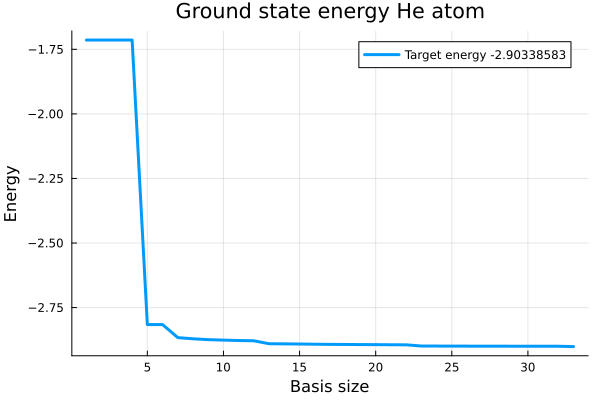


do_action - updated ecg_config.json with 32 action(s)

Writing inout file inout_1.txt

do_action - total wall-clock time: 113.35 s


In [1]:
# Load ECG_Julia and run this example.
# The package module is included directly (no Pkg.activate), so it works inside
# the Jupyter/IJulia kernel without switching environments. ECG_Julia's deps
# (Plots, Optim, ForwardDiff, JSON, Parameters, Distances) must be installed in
# the kernel's environment.
include("../ECG_Julia/src/ECG_Julia.jl")
using .ECG_Julia
ECG_Julia.run_ecg(".")


# Description of the modules

In [2]:
# Display Julia version information
versioninfo()

Julia Version 1.12.6
Commit 15346901f00 (2026-04-09 19:20 UTC)
Build Info:
  Official https://julialang.org release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
  CPU: 22 × Intel(R) Core(TM) Ultra 9 185H
  WORD_SIZE: 64
  LLVM: libLLVM-18.1.7 (ORCJIT, alderlake)
  GC: Built with stock GC
Threads: 1 default, 1 interactive, 1 GC (on 22 virtual cores)
